In [2]:
import pandas as pd
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

# Get the uploaded filename automatically
filename = next(iter(uploaded))

# Read the CSV file
df = pd.read_csv(filename)

# Display basic information
print("✅ Dataset loaded successfully!")
print("File:", filename)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Show first 5 rows
display(df.head())

Saving datafile (2).csv to datafile (2).csv
✅ Dataset loaded successfully!
File: datafile (2).csv
Rows: 55
Columns: 16


,Crop,Production 2006-07,Production 2007-08,Production 2008-09,Production 2009-10,Production 2010-11,Area 2006-07,Area 2007-08,Area 2008-09,Area 2009-10,Area 2010-11,Yield 2006-07,Yield 2007-08,Yield 2008-09,Yield 2009-10,Yield 2010-11
0,Total Foodgrains,158.8,168.6,171.3,159.4,178.9,128.5,128.8,127.6,126.0,131.7,123.6,130.9,134.3,126.5,135.9
1,Rice,200.8,207.9,213.3,191.6,206.4,168.5,168.9,175.1,161.2,164.8,119.2,123.1,121.8,118.9,125.2
2,Wheat,131.6,136.4,140.1,140.3,150.8,115.0,115.2,114.0,116.9,119.5,114.4,118.4,122.8,120.0,126.3
3,Jowar,124.3,137.8,126.0,116.5,121.8,120.7,110.6,107.3,111.0,105.2,103.0,124.6,117.4,105.0,115.8
4,Bajra,136.4,161.5,143.9,105.4,167.9,94.5,95.1,87.0,88.5,95.6,144.3,169.7,165.4,119.0,175.8


In [5]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Column names after cleaning:")
print(df.columns.tolist())

# Convert dataset into ML format
years = ['2006-07', '2007-08', '2008-09', '2009-10', '2010-11']

data = []

for _, row in df.iterrows():
    crop = row['Crop']

    for year in years:
        data.append({
            'Crop': crop,
            'Year': year,
            'Production': row[f'Production {year}'],
            'Area': row[f'Area {year}'],
            'Yield': row[f'Yield {year}']
        })

# Create ML dataset
ml_df = pd.DataFrame(data)

print("\n✅ Data converted successfully!")
print("Rows:", ml_df.shape[0])
print("Columns:", ml_df.shape[1])

display(ml_df.head(10))

Column names after cleaning:
['Crop', 'Production 2006-07', 'Production 2007-08', 'Production 2008-09', 'Production 2009-10', 'Production 2010-11', 'Area 2006-07', 'Area 2007-08', 'Area 2008-09', 'Area 2009-10', 'Area 2010-11', 'Yield 2006-07', 'Yield 2007-08', 'Yield 2008-09', 'Yield 2009-10', 'Yield 2010-11']

✅ Data converted successfully!
Rows: 275
Columns: 5


,Crop,Year,Production,Area,Yield
0,Total Foodgrains,2006-07,158.8,128.5,123.6
1,Total Foodgrains,2007-08,168.6,128.8,130.9
2,Total Foodgrains,2008-09,171.3,127.6,134.3
3,Total Foodgrains,2009-10,159.4,126.0,126.5
4,Total Foodgrains,2010-11,178.9,131.7,135.9
5,Rice,2006-07,200.8,168.5,119.2
6,Rice,2007-08,207.9,168.9,123.1
7,Rice,2008-09,213.3,175.1,121.8
8,Rice,2009-10,191.6,161.2,118.9
9,Rice,2010-11,206.4,164.8,125.2


In [6]:
# Check for missing values

print("Missing values in each column:")
print(ml_df.isnull().sum())

Missing values in each column:
Crop          0
Year          0
Production    0
Area          0
Yield         0
dtype: int64


In [7]:
# Create previous-year features for production prediction

model_data = ml_df.copy()

# Create previous year's values for each crop
model_data['Previous_Production'] = model_data.groupby('Crop')['Production'].shift(1)
model_data['Previous_Area'] = model_data.groupby('Crop')['Area'].shift(1)
model_data['Previous_Yield'] = model_data.groupby('Crop')['Yield'].shift(1)

# Remove rows where previous-year information is not available
model_data = model_data.dropna().reset_index(drop=True)

print("✅ ML dataset prepared!")
print("Rows:", model_data.shape[0])
print("Columns:", model_data.shape[1])

display(model_data.head(10))

✅ ML dataset prepared!
Rows: 220
Columns: 8


,Crop,Year,Production,Area,Yield,Previous_Production,Previous_Area,Previous_Yield
0,Total Foodgrains,2007-08,168.6,128.8,130.9,158.8,128.5,123.6
1,Total Foodgrains,2008-09,171.3,127.6,134.3,168.6,128.8,130.9
2,Total Foodgrains,2009-10,159.4,126.0,126.5,171.3,127.6,134.3
3,Total Foodgrains,2010-11,178.9,131.7,135.9,159.4,126.0,126.5
4,Rice,2007-08,207.9,168.9,123.1,200.8,168.5,119.2
5,Rice,2008-09,213.3,175.1,121.8,207.9,168.9,123.1
6,Rice,2009-10,191.6,161.2,118.9,213.3,175.1,121.8
7,Rice,2010-11,206.4,164.8,125.2,191.6,161.2,118.9
8,Wheat,2007-08,136.4,115.2,118.4,131.6,115.0,114.4
9,Wheat,2008-09,140.1,114.0,122.8,136.4,115.2,118.4


In [4]:
import pandas as pd
from google.colab import files

# ==============================
# 1. Upload dataset
# ==============================

uploaded = files.upload()
filename = next(iter(uploaded))

df = pd.read_csv(filename)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("✅ Dataset loaded!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# ==============================
# 2. Convert dataset to ML format
# ==============================

years = ['2006-07', '2007-08', '2008-09', '2009-10', '2010-11']

data = []

for _, row in df.iterrows():
    crop = row['Crop']

    for year in years:
        data.append({
            'Crop': crop,
            'Year': year,
            'Production': row[f'Production {year}'],
            'Area': row[f'Area {year}'],
            'Yield': row[f'Yield {year}']
        })

ml_df = pd.DataFrame(data)

print("\n✅ Dataset converted!")
print("ML dataset:", ml_df.shape)


# ==============================
# 3. Create previous-year data
# ==============================

model_data = ml_df.copy()

model_data['Previous_Production'] = (
    model_data.groupby('Crop')['Production'].shift(1)
)

model_data['Previous_Area'] = (
    model_data.groupby('Crop')['Area'].shift(1)
)

model_data['Previous_Yield'] = (
    model_data.groupby('Crop')['Yield'].shift(1)
)

# Remove first year of each crop
model_data = model_data.dropna().reset_index(drop=True)

print("\n✅ Previous-year features created!")
print("Model dataset:", model_data.shape)


# ==============================
# 4. Select X and y
# ==============================

X = model_data[
    ['Previous_Production',
     'Previous_Area',
     'Previous_Yield']
]

y = model_data['Production']

print("\n✅ X and y created!")
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

Saving datafile (2).csv to datafile (2).csv
✅ Dataset loaded!
Rows: 55
Columns: 16

✅ Dataset converted!
ML dataset: (275, 5)

✅ Previous-year features created!
Model dataset: (220, 8)

✅ X and y created!
X shape: (220, 3)
y shape: (220,)


,Previous_Production,Previous_Area,Previous_Yield
0,158.8,128.5,123.6
1,168.6,128.8,130.9
2,171.3,127.6,134.3
3,159.4,126.0,126.5
4,200.8,168.5,119.2


,Production
0,168.6
1,171.3
2,159.4
3,178.9
4,207.9


In [5]:
# Split data into training and testing sets

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("✅ Data split completed!")

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

✅ Data split completed!

Training data:
X_train: (176, 3)
y_train: (176,)

Testing data:
X_test: (44, 3)
y_test: (44,)


In [6]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully!")

✅ Linear Regression model trained successfully!


In [7]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("✅ Predictions completed!")

print("\nActual Production:")
print(y_test.values[:10])

print("\nPredicted Production:")
print(y_pred[:10])

✅ Predictions completed!

Actual Production:
[135.8 157.1 159.2 162.2 167.9 131.3 128.5 261.3 311.3 242.1]

Predicted Production:
[171.48902664 150.70508956 171.99942071 175.72559353 137.18992519
 181.3758375  136.57058187 135.50724395 240.33570083 328.45781408]


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("✅ Model Evaluation Results")
print("--------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

✅ Model Evaluation Results
--------------------------------
MAE  : 28.32
RMSE : 40.86
R²   : 0.76


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [10]:
# Make predictions using Random Forest

rf_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("✅ Random Forest Evaluation Results")
print("-----------------------------------")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.2f}")

✅ Random Forest Evaluation Results
-----------------------------------
MAE  : 30.26
RMSE : 41.10
R²   : 0.76


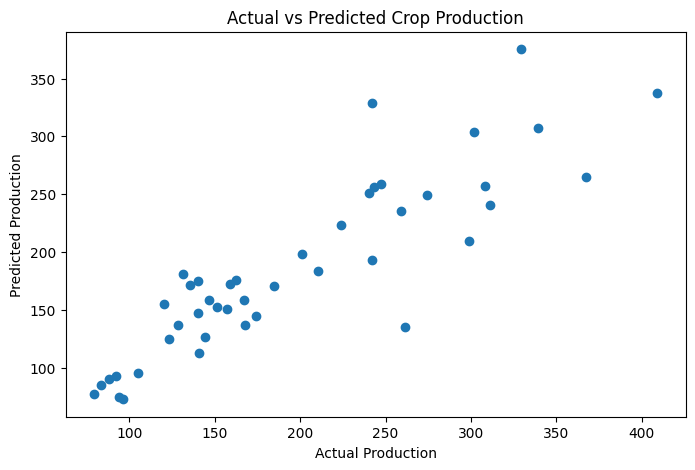

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Crop Production")

plt.show()

In [12]:
# Create a final results table

results = pd.DataFrame({
    'Actual Production': y_test.values,
    'Predicted Production': y_pred
})

# Calculate prediction error
results['Error'] = (
    results['Actual Production'] - results['Predicted Production']
)

# Show the first 10 results
print("✅ Final prediction results created!")

display(results.head(10))

✅ Final prediction results created!


,Actual Production,Predicted Production,Error
0,135.8,171.489027,-35.689027
1,157.1,150.705090,6.394910
2,159.2,171.999421,-12.799421
3,162.2,175.725594,-13.525594
4,167.9,137.189925,30.710075
5,131.3,181.375837,-50.075837
6,128.5,136.570582,-8.070582
7,261.3,135.507244,125.792756
8,311.3,240.335701,70.964299
9,242.1,328.457814,-86.357814


In [13]:
import joblib

# Save the best-performing model
joblib.dump(model, 'crop_production_model.pkl')

print("✅ Final Linear Regression model saved!")
print("File: crop_production_model.pkl")

✅ Final Linear Regression model saved!
File: crop_production_model.pkl


In [14]:
# Simple Crop Production Prediction

previous_production = float(input("Enter previous year Production: "))
previous_area = float(input("Enter previous year Area: "))
previous_yield = float(input("Enter previous year Yield: "))

input_data = [[
    previous_production,
    previous_area,
    previous_yield
]]

prediction = model.predict(input_data)

print("\n🌾 Predicted Crop Production:", round(prediction[0], 2))

Enter previous year Production: 2001
Enter previous year Area: 2001
Enter previous year Yield: 2001

🌾 Predicted Crop Production: 3571.67


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
# Save prediction results

results.to_csv("crop_production_predictions.csv", index=False)

print("✅ Prediction results saved!")
print("File: crop_production_predictions.csv")

✅ Prediction results saved!
File: crop_production_predictions.csv


In [16]:
# Save processed ML dataset

model_data.to_csv("processed_crop_data.csv", index=False)

print("✅ Processed dataset saved!")
print("File: processed_crop_data.csv")

✅ Processed dataset saved!
File: processed_crop_data.csv


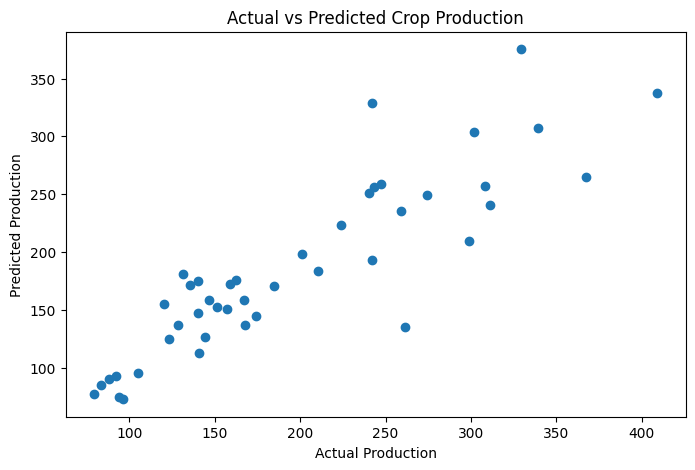

✅ Graph saved as actual_vs_predicted.png


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Crop Production")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

print("✅ Graph saved as actual_vs_predicted.png")

In [18]:
model_info = {
    "Project": "Prediction of Agriculture Crop Production in India",
    "Model": "Linear Regression",
    "Training Samples": len(X_train),
    "Testing Samples": len(X_test),
    "MAE": round(mae, 2),
    "RMSE": round(rmse, 2),
    "R2 Score": round(r2, 2)
}

print("✅ Final Model Information")
print("--------------------------------")

for key, value in model_info.items():
    print(f"{key}: {value}")

✅ Final Model Information
--------------------------------
Project: Prediction of Agriculture Crop Production in India
Model: Linear Regression
Training Samples: 176
Testing Samples: 44
MAE: 28.32
RMSE: 40.86
R2 Score: 0.76


In [19]:
from google.colab import files

files.download("crop_production_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
files.download("crop_production_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
files.download("processed_crop_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
files.download("actual_vs_predicted.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>